## Lab 1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]],dtype=torch.float32)

times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

model = nn.Sequential(nn.Linear(1, 1))





In [ ]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(distances)
    loss = loss_function(outputs,times)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0 :
        print(f"Epoch {epoch + 1} : loss = {loss.item()}")
    

In [ ]:
pip install matplotlib

In [ ]:
import helper
helper.plot_results(model, distances, times)

In [ ]:
distance_to_predict = 7.0

In [ ]:
with torch.no_grad():
    new_distance = torch.tensor([[distance_to_predict]],dtype=torch.float32)
    predicted_time = model(new_distance)
    # Use .item() to extract the scalar value from the tensor for printing
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

    # Use the scalar value in a conditional statement to make the final decision
    if predicted_time.item() > 30:
        print("\nDecision: Do NOT take the job. You will likely be late.")
    else:
        print("\nDecision: Take the job. You can make it!")

## Lab 2

In [1]:
import torch
import torch.nn as nn
import helper

In [2]:
#non linear data
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [5]:
#Helper utils
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time



def plot_data(distances, times, normalize=False):
    """
    Creates a scatter plot of the data points.

    Args:
        distances: The input data points for the x-axis.
        times: The target data points for the y-axis.
        normalize: A boolean flag indicating whether the data is normalized.
    """
    # Create a new figure with a specified size
    plt.figure(figsize=(8, 6))

    # Plot the data points as a scatter plot
    plt.plot(distances.numpy(), times.numpy(), color='orange', marker='o', linestyle='none', label='Actual Delivery Times')

    # Check if the data is normalized to set appropriate labels and title
    if normalize:
        # Set the plot title for normalized data
        plt.title('Normalized Delivery Data (Bikes & Cars)')
        # Set the x-axis label for normalized data
        plt.xlabel('Normalized Distance')
        # Set the y-axis label for normalized data
        plt.ylabel('Normalized Time')
        # Display the legend
        plt.legend()
        # Add a grid to the plot
        plt.grid(True)
        # Show the plot
        plt.show()

    # Handle the case for un-normalized data
    else:
        # Set the plot title for un-normalized data
        plt.title('Delivery Data (Bikes & Cars)')
        # Set the x-axis label for un-normalized data
        plt.xlabel('Distance (miles)')
        # Set the y-axis label for un-normalized data
        plt.ylabel('Time (minutes)')
        # Display the legend
        plt.legend()
        # Add a grid to the plot
        plt.grid(True)
        # Show the plot
        plt.show()
    
    

def plot_final_fit(model, distances, times, distances_norm, times_std, times_mean):
    """
    Plots the predictions of a trained model against the original data,
    after de-normalizing the predictions.

    Args:
        model: The trained model used for prediction.
        distances: The original, un-normalized input data.
        times: The original, un-normalized target data.
        distances_norm: The normalized input data for the model.
        times_std: The standard deviation used for de-normalization.
        times_mean: The mean value used for de-normalization.
    """
    # Set the model to evaluation mode
    model.eval()

    # Disable gradient calculations for prediction
    with torch.no_grad():
        # Get predictions from the model using normalized data
        predicted_norm = model(distances_norm)

    # De-normalize the predictions to their original scale
    predicted_times = (predicted_norm * times_std) + times_mean

    # Create a new figure for the plot
    plt.figure(figsize=(8, 6))

    # Plot the original data points
    plt.plot(distances.numpy(), times.numpy(), color='orange', marker='o', linestyle='none', label='Actual Data (Bikes & Cars)')

    # Plot the de-normalized predictions from the model
    plt.plot(distances.numpy(), predicted_times.numpy(), color='green', label='Non-Linear Model Predictions')

    # Set the title of the plot
    plt.title('Non-Linear Model Fit vs. Actual Data')
    # Set the x-axis label
    plt.xlabel('Distance (miles)')
    # Set the y-axis label
    plt.ylabel('Time (minutes)')
    # Add a legend to the plot
    plt.legend()
    # Enable the grid
    plt.grid(True)
    # Display the plot
    plt.show()

    

def plot_training_progress(epoch, loss, model, distances_norm, times_norm):
    """
    Plots the training progress of a model on normalized data,
    showing the current fit at each epoch.

    Args:
        epoch: The current training epoch number.
        loss: The loss value at the current epoch.
        model: The model being trained.
        distances_norm: The normalized input data.
        times_norm: The normalized target data.
    """
    # Clear the previous plot from the output cell
    clear_output(wait=True)

    # Make predictions using the current state of the model
    predicted_norm = model(distances_norm)

    # Convert tensors to NumPy arrays for plotting
    x_plot = distances_norm.numpy()
    y_plot = times_norm.numpy()
    
    # Detach predictions from the computation graph and convert to NumPy
    y_pred_plot = predicted_norm.detach().numpy()

    # Sort the data based on distance to ensure a smooth line plot
    sorted_indices = x_plot.argsort(axis=0).flatten()

    # Create a new figure for the plot
    plt.figure(figsize=(8, 6))

    # Plot the original normalized data points
    plt.plot(x_plot, y_plot, color='orange', marker='o', linestyle='none', label='Actual Normalized Data')

    # Plot the model's predictions as a line
    plt.plot(x_plot[sorted_indices], y_pred_plot[sorted_indices], color='green', label='Model Predictions')

    # Set the title of the plot, including the current epoch
    plt.title(f'Epoch: {epoch + 1} | Normalized Training Progress')
    # Set the x-axis label
    plt.xlabel('Normalized Distance')
    # Set the y-axis label
    plt.ylabel('Normalized Time')
    # Display the legend
    plt.legend()
    # Add a grid to the plot
    plt.grid(True)
    # Show the plot
    plt.show()

    # Pause briefly to allow the plot to be rendered
    time.sleep(0.05)

    

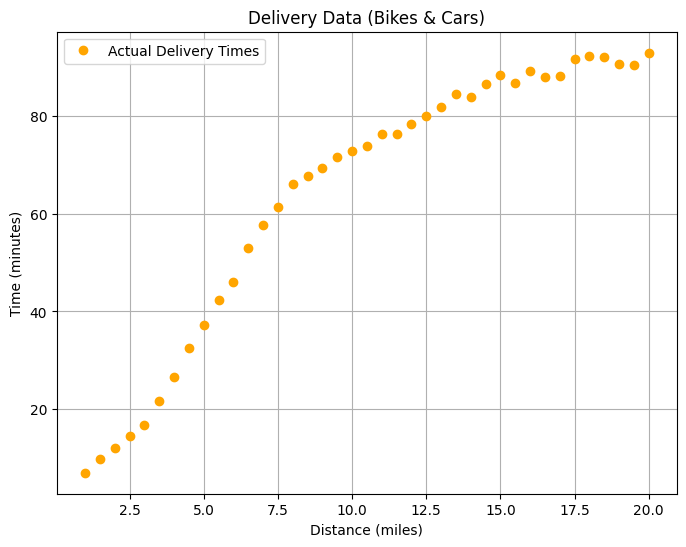

In [4]:
plot_data(distances,times)

In [5]:
# Calculate the mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# Calculate the mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# Apply standardization to the distances.
distances_norm = (distances - distances_mean) / distances_std

# Apply standardization to the times.
times_norm = (times - times_mean) / times_std

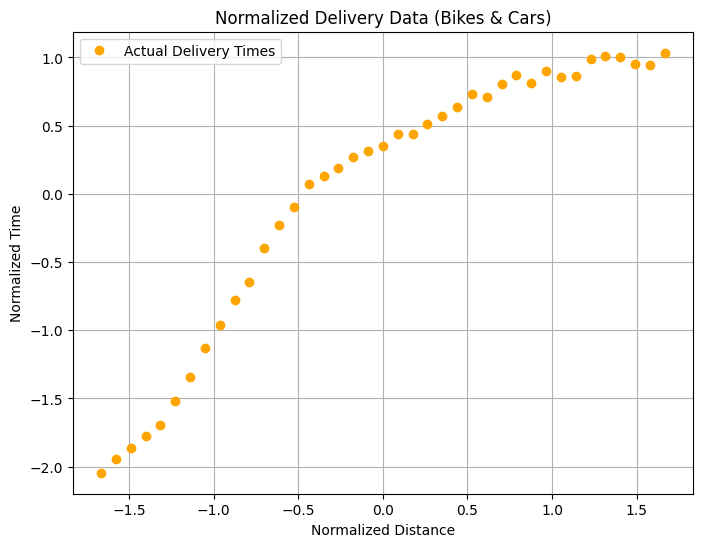

In [6]:
plot_data(distances_norm,times_norm,normalize=True)

In [8]:
import torch.optim as optim
torch.manual_seed(27)
model = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

In [9]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)

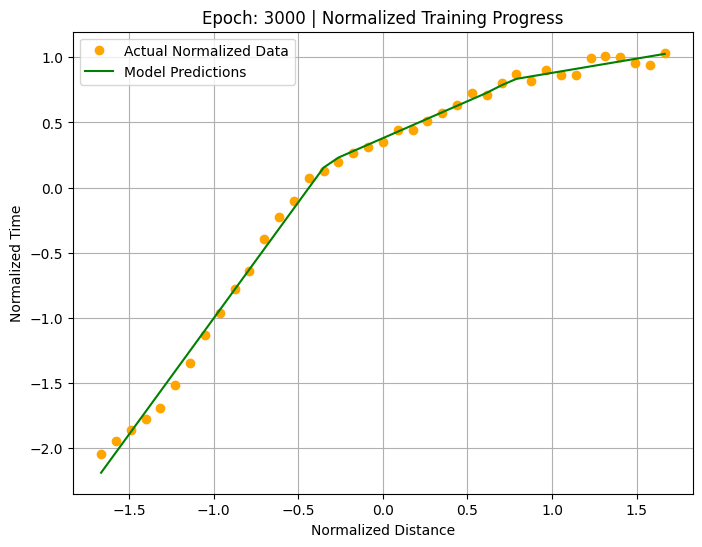


Training Complete

Final Loss : 0.0031437124125659466


In [11]:
#training loop
for epoch in range(3000):
    optimizer.zero_grad()
    outputs = model(distances_norm)
    loss = loss_function(outputs,times_norm)
    loss.backward()
    optimizer.step()
    if(epoch + 1) % 50 ==0:
        plot_training_progress(
            epoch = epoch,
            loss = loss,
            model = model,
            distances_norm = distances_norm,
            times_norm = times_norm
        )
print("\nTraining Complete")
print(f"\nFinal Loss : {loss.item()}")

In [12]:
distance_to_predict = 5.1

In [13]:
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # Normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    
    # Get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
    
    # De-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- Decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")
    
    # First, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 38.7 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.


## Lab 3

In [2]:
import torch
import numpy as np
import pandas as pd

In [10]:
x = torch.tensor([1,2,3])
print(x.dtype)

torch.int64


In [14]:
numpy_array = np.array([[1,2,3],[4,5,6]])
torch_tensor_from_numpy = torch.from_numpy(numpy_array)
print(torch_tensor_from_numpy)


tensor([[1, 2, 3],
        [4, 5, 6]])


In [13]:
df = pd.read_csv("data.csv")
all_values = df.values
tensor_from_df = torch.tensor(all_values)


In [15]:
zeros = torch.zeros(2,3)
zeros

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [16]:
ones = torch.ones(2,3)
ones

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [17]:
range_tensor = torch.arange(0,10,step=1)
range_tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [18]:
x = torch.tensor([[1,2,3],[4,5,6]])
print(x.shape)

torch.Size([2, 3])


In [19]:
expanded = x.unsqueeze(0)
expanded

tensor([[[1, 2, 3],
         [4, 5, 6]]])

## Module 2

In [1]:
import torch


In [2]:
torch.cuda.is_available()

False

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
#helper utils
import random
import torch

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from PIL import Image



def display_image(image, label, title, num_ticks=6, show_values=True):
    """
    Displays an image with its corresponding label and title.

    This function handles different image formats (PIL Image and PyTorch Tensor),
    normalizes the display range, and optionally overlays pixel values on the image.

    Args:
        image: The image data to be displayed. Can be a PIL Image or a PyTorch Tensor.
        label: The label associated with the image.
        title: The title for the plot.
        num_ticks (int, optional): The number of ticks to display on the color bar. Defaults to 6.
        show_values (bool, optional): If True, overlays the numerical value of each pixel on the image. Defaults to True.
    """
    # Initialize variables for value range and image data.
    vmin_val, vmax_val = None, None
    image_data = None

    # Check if the input is a PIL Image.
    if isinstance(image, Image.Image):
        # Set the value range for a standard 8-bit image.
        vmin_val = 0
        vmax_val = 255
        # Convert the PIL Image to a NumPy array.
        image_data = np.array(image)
    # Check if the input is a PyTorch Tensor.
    elif isinstance(image, torch.Tensor):
        # Convert the tensor to a NumPy array and remove any single-dimensional entries.
        image_np = image.numpy().squeeze()
        # Determine the min and max values from the tensor for normalization.
        vmin_val = image_np.min()
        vmax_val = image_np.max()
        # Assign the NumPy array to image_data.
        image_data = image_np
    # Handle unsupported image types.
    else:
        print("Warning: Unsupported image type.")
        return

    # Create a new figure for the plot.
    plt.figure(figsize=(9, 9))
    # Display the image data as a grayscale image.
    plt.imshow(image_data, cmap='gray', vmin=vmin_val, vmax=vmax_val)
    # Set the title of the plot with the provided title and label.
    plt.title(f'{title} | Label: {label}')

    # Check if pixel values should be displayed on the image.
    if show_values:
        # Calculate a threshold to determine the color of the text (black or white).
        threshold = (vmin_val + vmax_val) / 2.0
        # Get the dimensions of the image.
        height, width = image_data.shape
        
        # Iterate over each pixel to display its value.
        for y in range(height):
            for x in range(width):
                # Get the pixel value.
                value = image_data[y, x]
                # Set text color based on the pixel's brightness.
                text_color = "white" if value < threshold else "black"
                
                # Format the text to display, handling integers and floats differently.
                text_to_display = f"{value:.0f}" if isinstance(value, np.integer) else f"{value:.1f}"
                
                # Add the pixel value as text to the plot.
                plt.text(x, y, text_to_display, 
                         ha="center", va="center", color=text_color, fontsize=6)

    # Add a grid to the plot.
    plt.grid(True, color='red', alpha=0.3, zorder=2)
    # Set the x-axis ticks.
    plt.xticks(np.arange(0, 28, 4))
    # Set the y-axis ticks.
    plt.yticks(np.arange(0, 28, 4))
    
    # Add a color bar to the plot.
    cbar = plt.colorbar()
    # Create evenly spaced ticks for the color bar.
    ticks = np.linspace(vmin_val, vmax_val, num=num_ticks)
    # Set the ticks on the color bar.
    cbar.set_ticks(ticks)
    # Format the tick labels on the color bar.
    cbar.ax.set_yticklabels([f'{t:.2f}' for t in ticks])

    # Show the final plot.
    plt.show()
    
    
    
def display_predictions(model, test_loader, device):
    """
    Displays a grid of predictions for one random sample from each class.

    Args:
        model: The trained PyTorch model.
        test_loader: The DataLoader for the test set.
        device: The device (e.g., 'cuda' or 'cpu') to run inference on.
    """
    # Ensures the model is on the specified device and in evaluation mode.
    model.to(device)
    model.eval()

    # Creates a dictionary to store indices for each class.
    class_indices = {i: [] for i in range(10)}
    
    # Populates the dictionary with the indices of all samples for each class.
    for idx, (_, label) in enumerate(test_loader.dataset):
        class_indices[label].append(idx)
        
    # Selects one random index from the list of indices for each class.
    random_indices = [random.choice(indices) for indices in class_indices.values()]
    
    # Retrieves the images and corresponding labels using the randomly selected indices.
    sample_images = torch.stack([test_loader.dataset[i][0] for i in random_indices])
    sample_labels = [test_loader.dataset[i][1] for i in random_indices]

    # Temporarily disables gradient calculation for inference.
    with torch.no_grad():
        # Passes the selected images through the model to get outputs.
        outputs = model(sample_images.to(device))
        # Gets the predicted class for each image.
        _, predictions = torch.max(outputs, 1)

    # Creates a figure and a grid of subplots for displaying the images.
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    # Sets a main title for the entire figure.
    fig.suptitle('Model Predictions for a Sample of Each Class', fontsize=16)

    # Iterates through the subplots to display each image and its prediction.
    for i, ax in enumerate(axes.flat):
        # Extracts and prepares the image, true label, and predicted label for display.
        image = sample_images[i].cpu().squeeze()
        true_label = sample_labels[i]
        predicted_label = predictions[i].item()

        # Displays the image on the current subplot.
        ax.imshow(image, cmap='gray')
        
        # Sets the title of the subplot, with color indicating if the prediction is correct.
        title_color = 'green' if true_label == predicted_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
        
        # Hides the axes for a cleaner visual.
        ax.axis('off')

    # Adjusts the layout to prevent titles and labels from overlapping.
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Adjusts the vertical spacing between subplots.
    plt.subplots_adjust(hspace=0.3)
    
    # Displays the plot.
    plt.show()
    
    
    
def plot_metrics(train_loss, test_acc):
    """
    Displays side-by-side plots for training loss and test accuracy over epochs.

    Args:
        train_loss (list): A list of floating-point numbers representing the
                           average training loss for each epoch.
        test_acc (list): A list of floating-point numbers representing the
                         test accuracy for each epoch.
    """
    # Get the number of epochs from the length of the loss list
    num_epochs = len(train_loss)
    # Create a 1-based epoch range for the x-axis
    epochs = range(1, num_epochs + 1)

    # Create a figure and a set of subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- Plot 1: Training Loss ---
    ax1.plot(epochs, train_loss, marker='o', linestyle='-', color='royalblue')
    ax1.set_title('Training Loss Over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.grid(True)
    # Ensure the x-axis ticks are integers
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # --- Plot 2: Test Accuracy ---
    ax2.plot(epochs, test_acc, marker='o', linestyle='-', color='red')
    ax2.set_title('Test Accuracy Over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.grid(True)
    # Ensure the x-axis ticks are integers
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Adjust layout to prevent overlap and display the plots
    plt.tight_layout()
    plt.show()

In [5]:
data_path = "./data"

In [6]:
train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True
    
)

In [7]:
image_pil,label = train_dataset_without_transform[0]
print(type(image_pil))
print(image_pil.size)
print(type(label))
print(label)



<class 'PIL.Image.Image'>
(28, 28)
<class 'int'>
5


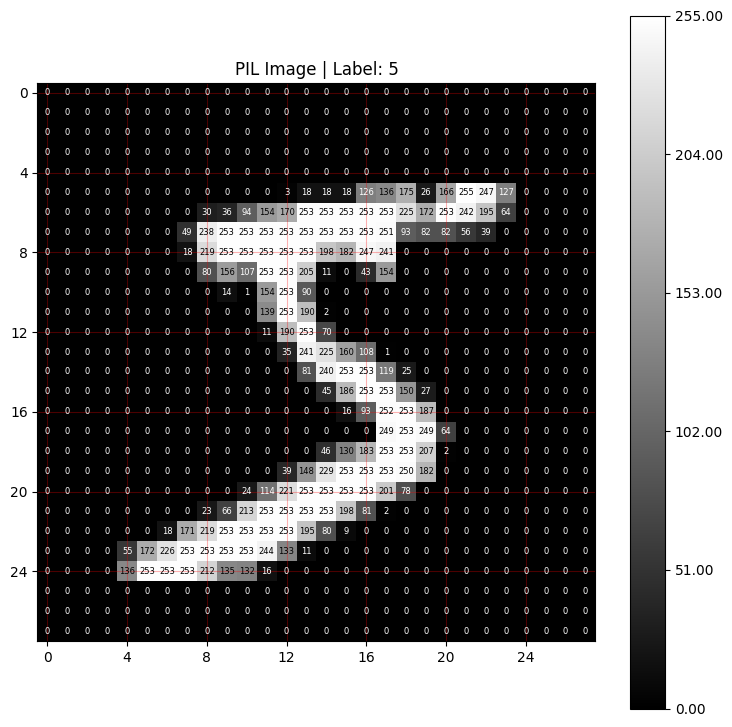

In [8]:
display_image(image_pil,label,"PIL Image",show_values=True)

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [10]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

In [11]:
image_tensor,label = train_dataset[0]
print(type(image_tensor))
print(image_tensor.shape)
print(type(label))


<class 'torch.Tensor'>
torch.Size([1, 28, 28])
<class 'int'>


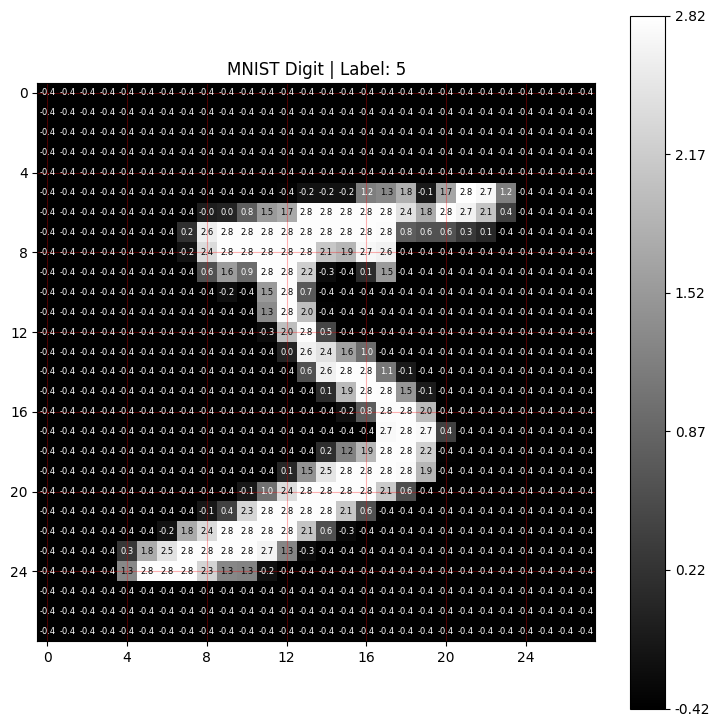

In [13]:
display_image(image_tensor,label,"MNIST Digit",show_values=True)


In [14]:
test_dataset = torchvision.datasets.MNIST(
    root = data_path,
    train=False,
    download = True,
    transform = transform
)

In [15]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=1000,shuffle=False)

In [16]:
class SimpleMNISTDNN(nn.Module):
    def __init__(self):
        super(SimpleMNISTDNN,self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
            )
    def forward(self,x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [17]:
model = SimpleMNISTDNN()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
                

In [21]:
def train_epoch(model, loss_function, optimizer, train_loader, device):
    model = model.to(device)
    model.train()
    epoch_loss = 0.0
    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    for batch_idx,(inputs, targets) in enumerate(train_loader):
        inputs,targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value

        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0)
        total_predictions += batch_size
        num_correct_in_batch = predicted_indices.eq(targets).sum().item()
        num_correct_predictions += num_correct_in_batch
        
        # Check if it's time to print a progress update
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches:
            # Calculate average loss and accuracy for the current interval
            avg_running_loss = running_loss / 134
            accuracy = 100. * num_correct_predictions / total_predictions
            
            # Print the progress update
            print(f'\tStep {batch_idx + 1}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')
            
            # Reset the trackers for the next reporting interval
            running_loss = 0.0
            num_correct_predictions = 0
            total_predictions = 0
        # Calculate the average loss for the entire epoch
    avg_epoch_loss = epoch_loss / total_batches
    # Return the trained model and the average epoch loss
    return model, avg_epoch_loss

In [19]:
def evaluate(model, test_loader, device):
    """
    Evaluates the model's accuracy on a test dataset.

    This function sets the model to evaluation mode, iterates through the test data,
    and calculates the percentage of correct predictions.

    Args:
        model: The neural network model to be evaluated.
        test_loader: A data loader containing the test dataset.
        device: The device (e.g., 'cpu' or 'cuda') to run the evaluation on.

    Returns:
        The accuracy of the model on the test dataset as a percentage.
    """
    # Sets the model to evaluation mode.
    model.eval()
    # Initializes a counter for correct predictions.
    num_correct_predictions = 0
    # Initializes a counter for the total number of predictions.
    total_predictions = 0

    # Disables gradient calculation to reduce memory usage and speed up computations.
    with torch.no_grad():
        # Iterates over all batches in the test data loader.
        for inputs, targets in test_loader:
            # Moves the input data and targets to the specified device.
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Performs a forward pass to get the model's output.
            outputs = model(inputs)
    # Retrieves the index of the highest value in the output tensor, which represents the predicted class.
            _, predicted_indices = outputs.max(1)
            
            # Gets the size of the current batch.
            batch_size = targets.size(0)
            # Adds the batch size to the total number of predictions.
            total_predictions = total_predictions + batch_size
            
            # Compares the predicted indices with the actual target values.
            correct_predictions = predicted_indices.eq(targets)
            # Sums the correct predictions in the current batch.
            num_correct_in_batch = correct_predictions.sum().item()
            # Adds the correct predictions from the current batch to the total count.
            num_correct_predictions = num_correct_predictions + num_correct_in_batch

    # Calculates the overall accuracy as a percentage.
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100
    # Prints the calculated accuracy to the console.
    print((f'\tAccuracy - {accuracy_percentage:.2f}%'))
    
    return accuracy_percentage

In [22]:
# Set the total number of training epochs (Feel free to set a different number)
num_epochs = 5

# Initialize lists to store metrics from each epoch for later analysis
train_loss = []
test_acc = []

# Begin the training and evaluation process
for epoch in range(num_epochs):
    print(f'\n[Training] Epoch {epoch+1}:')
    # Call the training function to train the model for one epoch
    trained_model, loss = train_epoch(model, loss_function, optimizer, train_loader, device)
    # Store the average training loss for the epoch
    train_loss.append(loss)
    
    print(f'[Testing] Epoch {epoch+1}:')
    # Call the evaluation function to measure performance on the test set
    accuracy = evaluate(trained_model, test_loader, device)
    # Store the test accuracy for the epoch
    test_acc.append(accuracy)


[Training] Epoch 1:
	Step 134/938 - Loss: 0.557 | Acc: 83.91%
	Step 268/938 - Loss: 0.308 | Acc: 91.11%
	Step 402/938 - Loss: 0.240 | Acc: 93.04%
	Step 536/938 - Loss: 0.190 | Acc: 94.48%
	Step 670/938 - Loss: 0.172 | Acc: 95.29%
	Step 804/938 - Loss: 0.169 | Acc: 95.03%
	Step 938/938 - Loss: 0.152 | Acc: 95.35%
[Testing] Epoch 1:
	Accuracy - 96.16%

[Training] Epoch 2:
	Step 134/938 - Loss: 0.129 | Acc: 96.04%
	Step 268/938 - Loss: 0.111 | Acc: 96.72%
	Step 402/938 - Loss: 0.116 | Acc: 96.42%
	Step 536/938 - Loss: 0.109 | Acc: 96.71%
	Step 670/938 - Loss: 0.107 | Acc: 96.62%
	Step 804/938 - Loss: 0.108 | Acc: 96.88%
	Step 938/938 - Loss: 0.100 | Acc: 96.97%
[Testing] Epoch 2:
	Accuracy - 96.73%

[Training] Epoch 3:
	Step 134/938 - Loss: 0.079 | Acc: 97.49%
	Step 268/938 - Loss: 0.084 | Acc: 97.53%
	Step 402/938 - Loss: 0.077 | Acc: 97.61%
	Step 536/938 - Loss: 0.080 | Acc: 97.43%
	Step 670/938 - Loss: 0.066 | Acc: 97.81%
	Step 804/938 - Loss: 0.078 | Acc: 97.63%
	Step 938/938 - Loss: